# **Notebook setup and dataset path**

In [1]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("GPUs:", tf.config.list_physical_devices('GPU'))

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = "/content/drive/MyDrive/AI and Machine Learning/fruitdataset"
print(os.listdir(base_dir))  # should show ['train', 'test', 'predict']

Mounted at /content/drive
['predict', 'train', 'test']


# **2.5 Part A: Designing and Analyzing CNNs from Scratch**

## **2.5.1 Data Understanding, Analysis, Visualization and Cleaning**

### **(a) What does the dataset represent?**<br>
This dataset consists of color images of 10 fruit types, where each image is labeled with its fruit class (apple, banana, avocado, cherry, kiwi, mango, orange, pineapple, strawberries, watermelon). It is designed for supervised image classification.

In [3]:
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

classes = sorted(os.listdir(train_dir))
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['Apple', 'Banana', 'avocado', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']
Number of classes: 10


### **(b) How many total images are in the dataset?**<br>
The dataset contains 2,301 images in the training set and 1,025 images in the test set, giving a total of 3,326 images. The training set is used to learn the model parameters, while the separate test set is reserved for final performance evaluation.

In [4]:
def count_images(folder):
    class_counts = {}
    total = 0
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            n = len(os.listdir(cls_path))
            class_counts[cls] = n
            total += n
    return total, class_counts

total_train, train_counts = count_images(train_dir)
total_test, test_counts = count_images(test_dir)

print("Total train images:", total_train)
print("Total test images:", total_test)
train_counts

Total train images: 2301
Total test images: 1025


{'Apple': 230,
 'avocado': 230,
 'Banana': 230,
 'kiwi': 230,
 'cherry': 230,
 'pinenapple': 230,
 'orange': 230,
 'strawberries': 230,
 'mango': 231,
 'watermelon': 230}

### **(c) What is the distribution of images across different classes?**<br>
The dataset is approximately class‑balanced. Each of the 10 fruit classes (apple, avocado, banana, kiwi, cherry, pineapple, orange, strawberries, mango and watermelon) has around 230 images in the training set. This means no single class dominates the dataset, which is helpful for training a fair classification model.

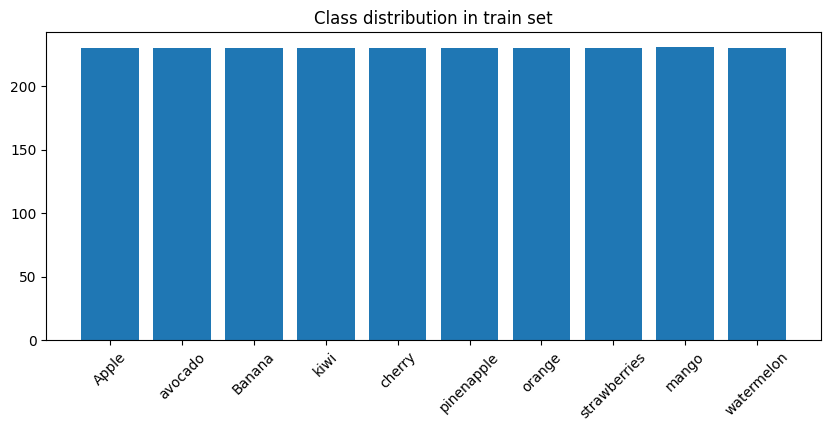

In [5]:
plt.figure(figsize=(10,4))
plt.bar(train_counts.keys(), train_counts.values())
plt.xticks(rotation=45)
plt.title("Class distribution in train set")
plt.show()

### **(d) How is the dataset split into training and validation sets? Justify your choice.**
I used Keras’ ImageDataGenerator with a validation_split of 0.2 to randomly split the original training folder into 80% training and 20% validation. Concretely, this produced 1,841 training images and 460 validation images across the 10 classes. An 80/20 split gives enough data for the model to learn while still keeping a separate, representative set for tuning hyperparameters and monitoring overfitting.



In [6]:
img_size = (128, 128)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # 80% train, 20% validation
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 1841 images belonging to 10 classes.
Found 460 images belonging to 10 classes.


### **(e) What preprocessing techniques (e.g., resizing, normalization) were applied?**<br>
Before feeding the images into the network, I resized all images to a fixed resolution of 128×128 pixels using Keras’ flow_from_directory. I also normalized the pixel values by rescaling them from the original 0–255 range to 0–1 using rescale = 1./255 in ImageDataGenerator. These preprocessing steps ensure that all inputs have the same size and a consistent numeric scale, which helps the CNN train more stably.

### **(f) What data generators, if any, were used for preprocessing and augmentation?**<br>
I used Keras’ ImageDataGenerator to handle preprocessing and dataset splitting. For the baseline model, the generator applied rescaling (rescale = 1./255) and performed an 80/20 train–validation split using the validation_split argument together with subset='training' and subset='validation'. This generator also reads images from the class folders, resizes them to 128×128 and yields mini‑batches during training.

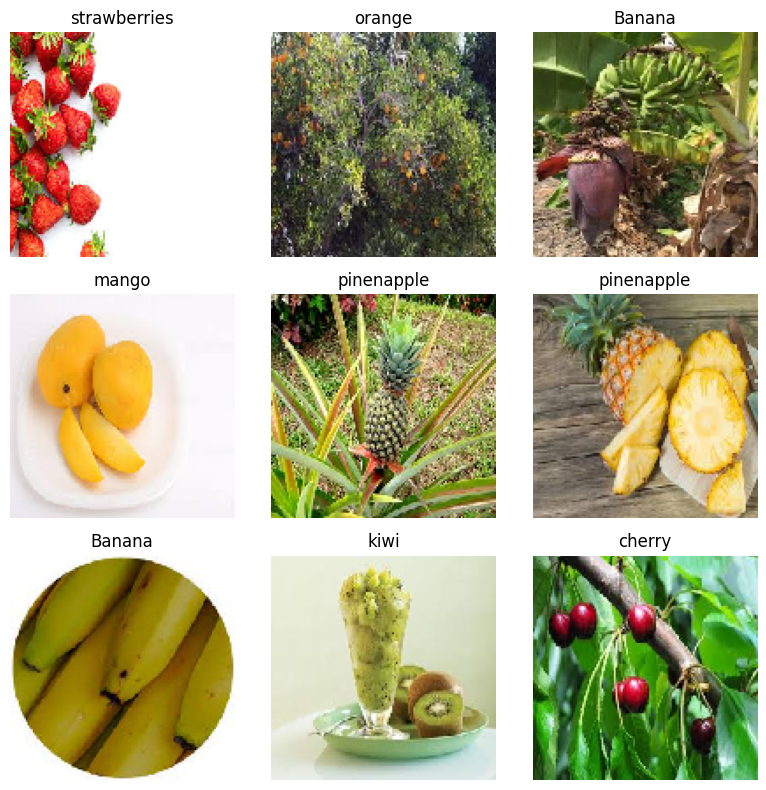

In [7]:
x_batch, y_batch = next(train_gen)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(classes[np.argmax(y_batch[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

# **2.5.2 Design, Train, and Evaluate a Baseline Model**

## **1. Model Architecture:**

In [8]:
num_classes = train_gen.num_classes

baseline_model = models.Sequential([
    layers.Input(shape=img_size + (3,)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,315,306 (12.65 MB)

 Trainable params: 3,315,306 (12.65 MB)

 Non-trainable params: 0 (0.00 B)

## **2. Model Training:**

In [9]:
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    train_gen,
    epochs=15,            # adjust if over/underfitting
    validation_data=val_gen
)


Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 751s 13s/step - accuracy: 0.1988 - loss: 2.0985 - val_accuracy: 0.2239 - val_loss: 1.9187
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.3107 - loss: 1.7256 - val_accuracy: 0.4152 - val_loss: 1.5511
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.4394 - loss: 1.4775 - val_accuracy: 0.3891 - val_loss: 1.4624
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - accuracy: 0.4976 - loss: 1.3528 - val_accuracy: 0.4457 - val_loss: 1.4498
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 159ms/step - accuracy: 0.5568 - loss: 1.2223 - val_accuracy: 0.4652 - val_loss: 1.3433
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - accuracy: 0.6073 - loss: 1.0669 - val_accuracy: 0.5174 - val_loss: 1.3123
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.6790 - loss: 0.8839 - val_accuracy: 0.5478 - val_loss: 1.1956
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.7447 - loss: 0.7062 - val_accuracy: 0.

## **Training vs validation loss curves over epochs**

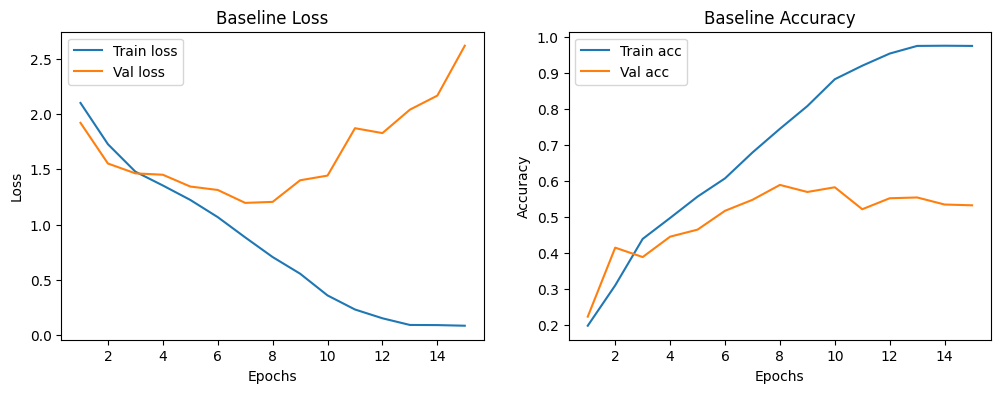

In [10]:
def plot_history(history, title_prefix=""):
    epochs = range(1, len(history.history['loss'])+1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, history.history['loss'], label='Train loss')
    plt.plot(epochs, history.history['val_loss'], label='Val loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, history.history['accuracy'], label='Train acc')
    plt.plot(epochs, history.history['val_accuracy'], label='Val acc')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

    plt.show()

plot_history(history_baseline, "Baseline")

## **3. Model Evaluation:**

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

val_gen.reset()
y_prob = baseline_model.predict(val_gen)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_gen.classes

target_names = list(train_gen.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=target_names))

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step
              precision    recall  f1-score   support

       Apple       0.54      0.41      0.47        46
      Banana       0.29      0.61      0.39        46
     avocado       0.50      0.37      0.42        46
      cherry       0.55      0.63      0.59        46
        kiwi       0.47      0.43      0.45        46
       mango       0.50      0.22      0.30        46
      orange       0.83      0.74      0.78        46
  pinenapple       0.74      0.61      0.67        46
strawberries       0.55      0.83      0.66        46
  watermelon       0.73      0.48      0.58        46

    accuracy                           0.53       460
   macro avg       0.57      0.53      0.53       460
weighted avg       0.57      0.53      0.53       460



### **Confusion matrix:**

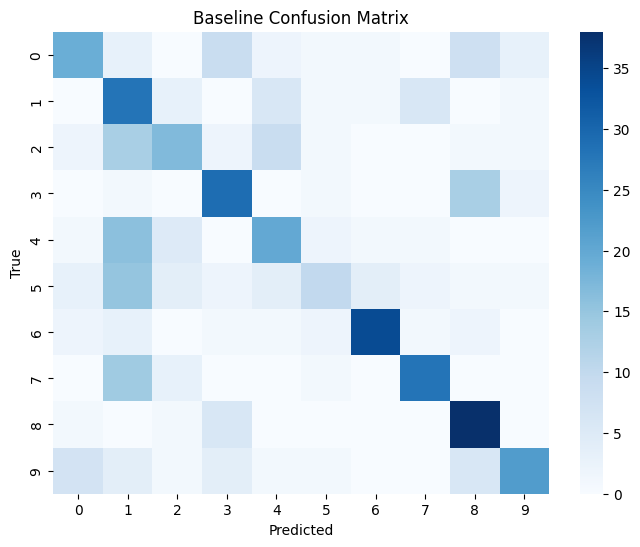

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

### **Inference on sample images from predict:**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step


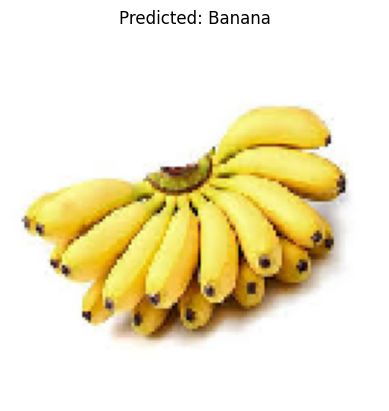

In [13]:
from tensorflow.keras.utils import load_img, img_to_array

predict_dir = os.path.join(base_dir, "predict")
sample_img = os.path.join(predict_dir, os.listdir(predict_dir)[0])

img = load_img(sample_img, target_size=img_size)
img_arr = img_to_array(img)/255.
img_batch = np.expand_dims(img_arr, axis=0)

pred = baseline_model.predict(img_batch)
pred_class = target_names[np.argmax(pred)]

plt.imshow(img)
plt.title(f"Predicted: {pred_class}")
plt.axis("off")
plt.show()

## **Key observations**<br>
The baseline model achieves about 56% validation accuracy, with per‑class F1‑scores between roughly 0.42 and 0.69. Some fruits like strawberries and pineapple have higher precision/recall, while visually similar classes show more confusion in the matrix. The training curves show train loss decreasing and accuracy approaching 1.0, but validation loss increases after about 7–8 epochs and validation accuracy plateaus around 0.6, indicating overfitting. Sample inference on unseen images (e.g., bananas) shows that the model can correctly classify clear examples, but performance on harder cases is limited.



# **2.5.3 Deeper Architecture with Regularization Layer:**

## **1. Model Architecture:**

In [14]:
train_aug_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_gen_aug = train_aug_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen_aug = train_aug_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 1841 images belonging to 10 classes.
Found 460 images belonging to 10 classes.


### **Visualise some augmented images:**

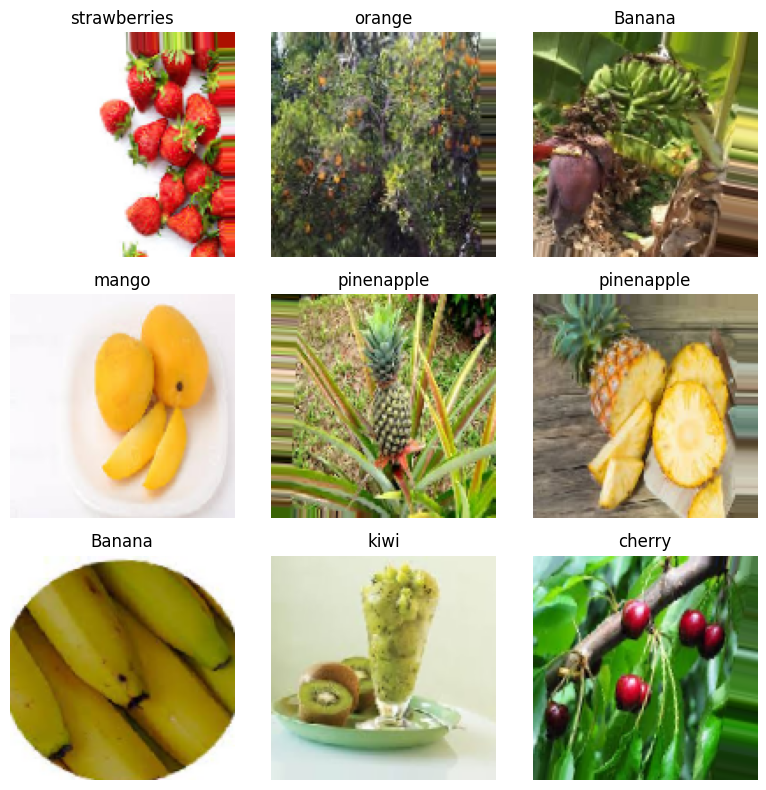

In [15]:
x_batch, y_batch = next(train_gen_aug)
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_batch[i])
    plt.title(target_names[np.argmax(y_batch[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

### **Deeper model:**

In [16]:
deeper_model = models.Sequential([
    layers.Input(shape=img_size + (3,)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 124, 124, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 58, 58, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 29, 29, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 27, 27, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 27, 27, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,049,578 (19.26 MB)

 Trainable params: 5,048,618 (19.26 MB)

 Non-trainable params: 960 (3.75 KB)

# **2. Model Training:**

Epoch 1/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 46s 543ms/step - accuracy: 0.2928 - loss: 1.9781 - val_accuracy: 0.1000 - val_loss: 2.8001
Epoch 2/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 315ms/step - accuracy: 0.3927 - loss: 1.5706 - val_accuracy: 0.1000 - val_loss: 3.6659
Epoch 3/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 321ms/step - accuracy: 0.4699 - loss: 1.4219 - val_accuracy: 0.1000 - val_loss: 4.3920
Epoch 4/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 343ms/step - accuracy: 0.4997 - loss: 1.3475 - val_accuracy: 0.1109 - val_loss: 3.4296
Epoch 5/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 323ms/step - accuracy: 0.5492 - loss: 1.2514 - val_accuracy: 0.1217 - val_loss: 3.3966
Epoch 6/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 328ms/step - accuracy: 0.5546 - loss: 1.2114 - val_accuracy: 0.1174 - val_loss: 3.5695
Epoch 7/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 331ms/step - accuracy: 0.5747 - loss: 1.1846 - val_accuracy: 0.1370 - val_loss: 3.2997
Epoch 8/20
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 312ms/step - accuracy: 0.5850 - loss: 1.1751 - val_accu

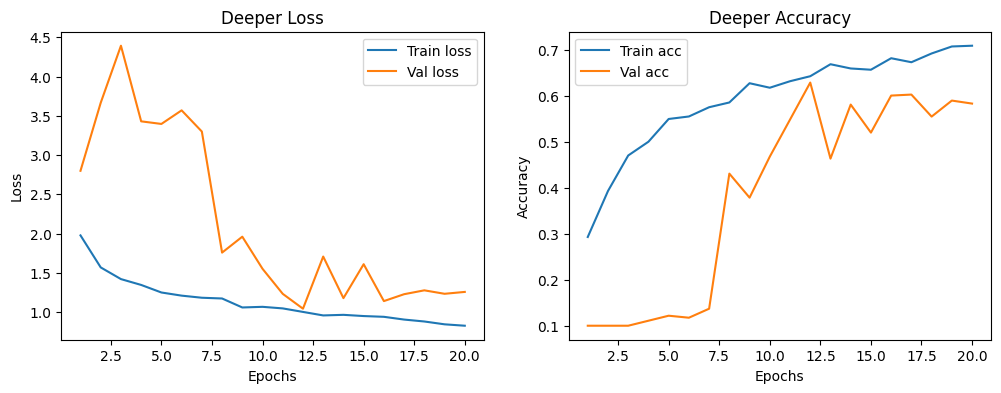

Deeper model training time (s): 402.76065135002136


In [17]:
import time

deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_deeper = deeper_model.fit(
    train_gen_aug,
    epochs=20,
    validation_data=val_gen_aug
)
deeper_train_time = time.time() - start_time

plot_history(history_deeper, "Deeper")
print("Deeper model training time (s):", deeper_train_time)

# **3. Model Evaluation:**

In [18]:
val_gen_aug.reset()
y_prob_d = deeper_model.predict(val_gen_aug)
y_pred_d = np.argmax(y_prob_d, axis=1)
y_true_d = val_gen_aug.classes

print(classification_report(y_true_d, y_pred_d, target_names=target_names))

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step
              precision    recall  f1-score   support

       Apple       0.69      0.63      0.66        46
      Banana       0.41      0.33      0.36        46
     avocado       0.46      0.28      0.35        46
      cherry       0.88      0.63      0.73        46
        kiwi       0.49      0.80      0.61        46
       mango       0.48      0.26      0.34        46
      orange       1.00      0.46      0.63        46
  pinenapple       0.72      0.63      0.67        46
strawberries       0.70      0.96      0.81        46
  watermelon       0.42      0.87      0.57        46

    accuracy                           0.58       460
   macro avg       0.63      0.58      0.57       460
weighted avg       0.63      0.58      0.57       460



# **2.5.4 Experimentation and Comparative Analysis:**

## **Optimizer Analysis: SGD vs Adam**

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 35s 457ms/step - accuracy: 0.6089 - loss: 1.0912 - val_accuracy: 0.1935 - val_loss: 4.7712
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.6795 - loss: 0.9151 - val_accuracy: 0.4674 - val_loss: 1.8664
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 343ms/step - accuracy: 0.6687 - loss: 0.9460 - val_accuracy: 0.2587 - val_loss: 4.5729
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.6420 - loss: 1.0512 - val_accuracy: 0.2587 - val_loss: 3.1548
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 304ms/step - accuracy: 0.6926 - loss: 0.8833 - val_accuracy: 0.5065 - val_loss: 1.9769
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 20s 345ms/step - accuracy: 0.7181 - loss: 0.8366 - val_accuracy: 0.5717 - val_loss: 1.2926
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.6953 - loss: 0.8646 - val_accuracy: 0.5696 - val_loss: 1.2127
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 307ms/step - accuracy: 0.7224 - loss: 0.8189 - val_accu

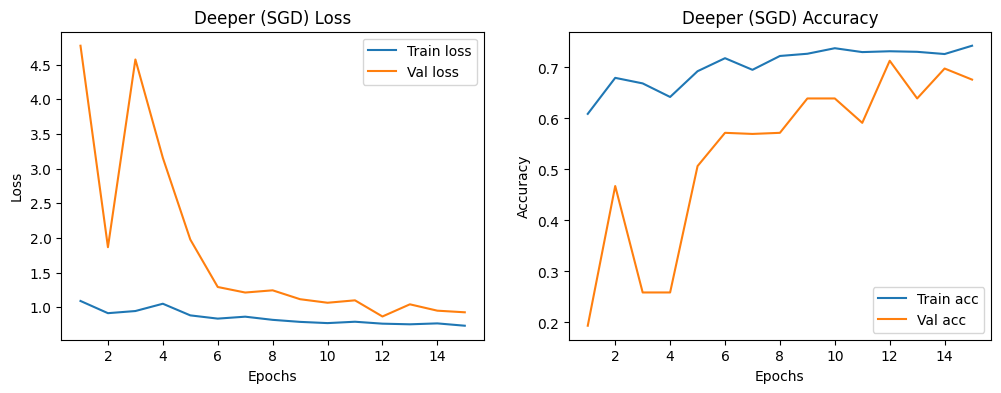

In [19]:
deeper_sgd = keras.models.clone_model(deeper_model)
deeper_sgd.set_weights(deeper_model.get_weights())  # optional or start fresh

deeper_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_deeper_sgd = deeper_sgd.fit(
    train_gen_aug,
    epochs=15,
    validation_data=val_gen_aug
)

plot_history(history_deeper_sgd, "Deeper (SGD)")

# The deeper model was trained first with Adam and then with SGD (with momentum). Both optimizers achieved similar validation accuracy (~70%) and loss, although Adam converged faster during the early epochs. This suggests that, for this dataset and architecture, Adam provides good out-of-the-box performance, while SGD with momentum can reach comparable performance with slightly longer training.

## **Ablation Study**

Epoch 1/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 30s 407ms/step - accuracy: 0.3954 - loss: 1.6901 - val_accuracy: 0.1587 - val_loss: 2.4758
Epoch 2/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 309ms/step - accuracy: 0.4823 - loss: 1.3926 - val_accuracy: 0.1130 - val_loss: 3.2984
Epoch 3/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 306ms/step - accuracy: 0.5530 - loss: 1.2250 - val_accuracy: 0.1435 - val_loss: 2.8490
Epoch 4/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 326ms/step - accuracy: 0.5839 - loss: 1.1487 - val_accuracy: 0.1435 - val_loss: 3.1214
Epoch 5/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.6317 - loss: 1.0613 - val_accuracy: 0.1522 - val_loss: 3.8221
Epoch 6/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 308ms/step - accuracy: 0.6464 - loss: 1.0220 - val_accuracy: 0.2435 - val_loss: 2.5999
Epoch 7/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 19s 321ms/step - accuracy: 0.6442 - loss: 0.9880 - val_accuracy: 0.3391 - val_loss: 2.2507
Epoch 8/15
58/58 ━━━━━━━━━━━━━━━━━━━━ 18s 312ms/step - accuracy: 0.6502 - loss: 0.9625 - val_accu

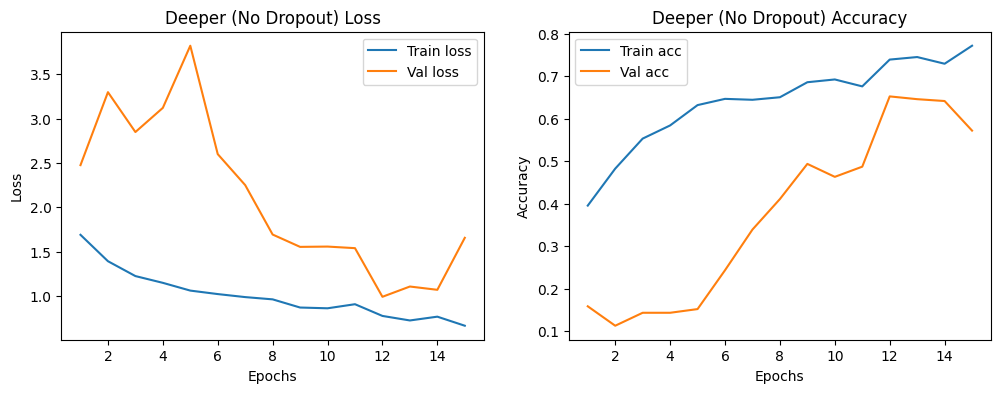

In [20]:
deeper_no_dropout = models.Sequential([
    layers.Input(shape=img_size + (3,)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

deeper_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_no_dropout = deeper_no_dropout.fit(
    train_gen_aug,
    epochs=15,
    validation_data=val_gen_aug
)

plot_history(history_no_dropout, "Deeper (No Dropout)")

# **2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).**

## **2.6.1 Loading and Adapting a Pre- Trained Model:**

In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_size_tl = (224, 224)

tl_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen_tl = tl_datagen.flow_from_directory(
    train_dir,
    target_size=img_size_tl,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen_tl = tl_datagen.flow_from_directory(
    train_dir,
    target_size=img_size_tl,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 1841 images belonging to 10 classes.
Found 460 images belonging to 10 classes.


In [22]:
base_model = MobileNetV2(
    input_shape=img_size_tl + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # feature extraction stage

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
inputs = keras.Input(shape=img_size_tl + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs)
tl_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **2.6.2 Model Training and Fine- Tuning:**

### **(a) Feature Extraction**

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 56s 658ms/step - accuracy: 0.6165 - loss: 1.1922 - val_accuracy: 0.9087 - val_loss: 0.3404
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.8599 - loss: 0.4728 - val_accuracy: 0.9217 - val_loss: 0.2305
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.9109 - loss: 0.2781 - val_accuracy: 0.9326 - val_loss: 0.1995
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9321 - loss: 0.2204 - val_accuracy: 0.9326 - val_loss: 0.1922
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.9375 - loss: 0.1875 - val_accuracy: 0.9283 - val_loss: 0.1754
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.9614 - loss: 0.1260 - val_accuracy: 0.9413 - val_loss: 0.1732
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.9658 - loss: 0.1138 - val_accuracy: 0.9370 - val_loss: 0.1807
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.9804 - loss: 0.0833 - val_accu

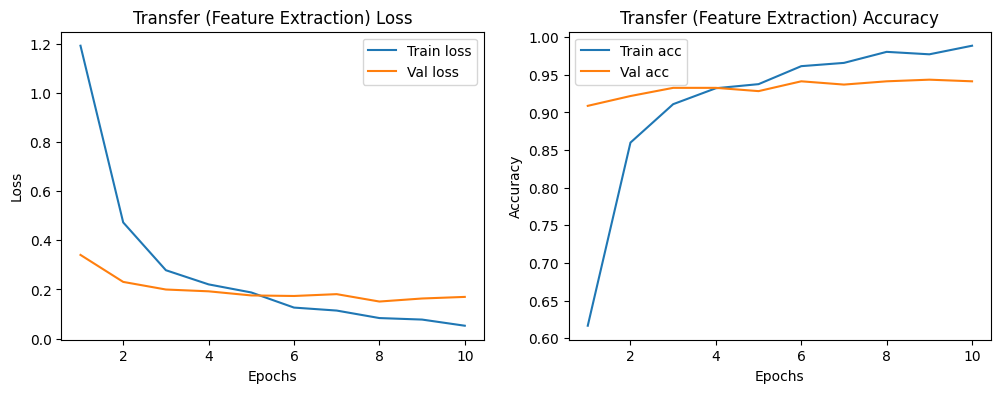

In [24]:
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tl_fe = tl_model.fit(
    train_gen_tl,
    epochs=10,
    validation_data=val_gen_tl
)

plot_history(history_tl_fe, "Transfer (Feature Extraction)")

### **(b) Fine-Tuning**

Epoch 1/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 42s 461ms/step - accuracy: 0.9028 - loss: 0.2829 - val_accuracy: 0.9217 - val_loss: 0.2980
Epoch 2/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step - accuracy: 0.9609 - loss: 0.1072 - val_accuracy: 0.9370 - val_loss: 0.2414
Epoch 3/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9734 - loss: 0.0798 - val_accuracy: 0.9391 - val_loss: 0.2243
Epoch 4/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.9810 - loss: 0.0564 - val_accuracy: 0.9457 - val_loss: 0.2263
Epoch 5/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 168ms/step - accuracy: 0.9908 - loss: 0.0300 - val_accuracy: 0.9435 - val_loss: 0.2135
Epoch 6/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.9962 - loss: 0.0219 - val_accuracy: 0.9457 - val_loss: 0.2371
Epoch 7/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.9973 - loss: 0.0188 - val_accuracy: 0.9522 - val_loss: 0.1744
Epoch 8/10
58/58 ━━━━━━━━━━━━━━━━━━━━ 9s 162ms/step - accuracy: 0.9935 - loss: 0.0220 - val_accura

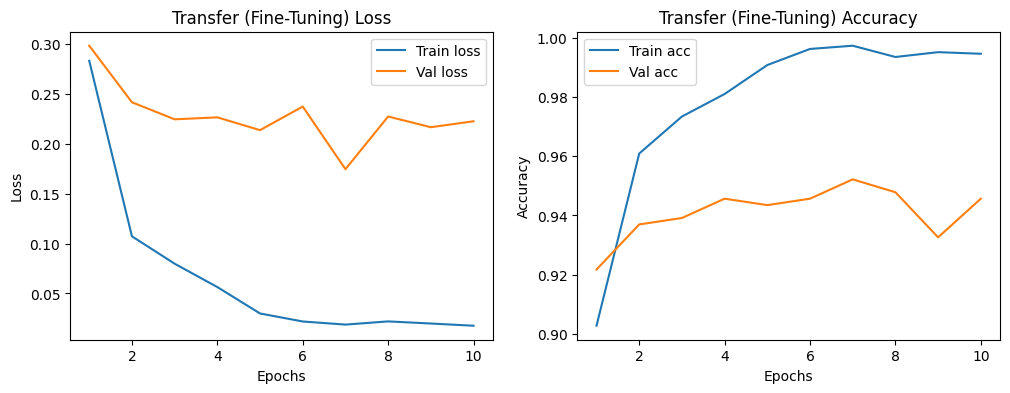

In [25]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_tl_ft = tl_model.fit(
    train_gen_tl,
    epochs=10,
    validation_data=val_gen_tl
)

plot_history(history_tl_ft, "Transfer (Fine-Tuning)")

# **2.6.3 Model Evaluation and Prediction**

## **Evaluate on validation and test sets:**

In [26]:
# Validation performance
val_gen_tl.reset()
y_prob_tl = tl_model.predict(val_gen_tl)
y_pred_tl = np.argmax(y_prob_tl, axis=1)
y_true_tl = val_gen_tl.classes

print(classification_report(y_true_tl, y_pred_tl, target_names=target_names))

15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 513ms/step
              precision    recall  f1-score   support

       Apple       0.94      0.96      0.95        46
      Banana       1.00      0.83      0.90        46
     avocado       0.96      1.00      0.98        46
      cherry       0.96      0.98      0.97        46
        kiwi       0.98      0.87      0.92        46
       mango       0.76      0.96      0.85        46
      orange       0.98      0.91      0.94        46
  pinenapple       1.00      1.00      1.00        46
strawberries       1.00      0.96      0.98        46
  watermelon       0.96      1.00      0.98        46

    accuracy                           0.95       460
   macro avg       0.95      0.95      0.95       460
weighted avg       0.95      0.95      0.95       460



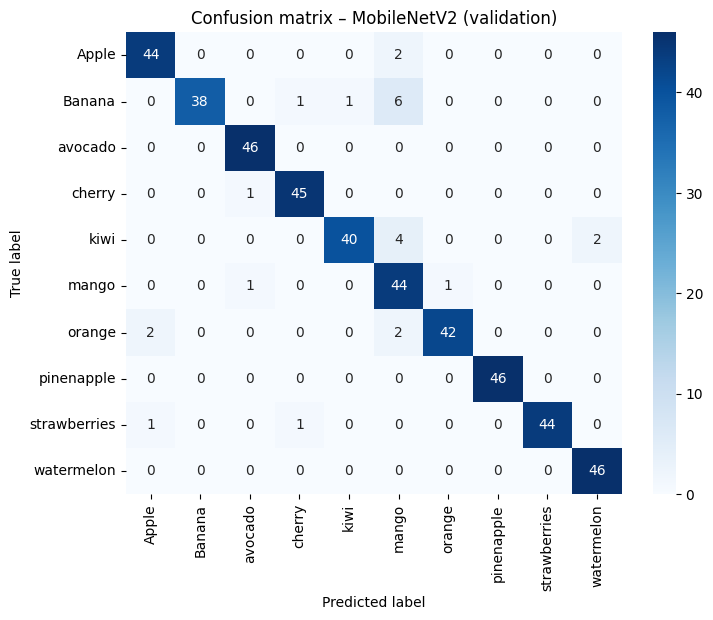

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# y_true_tl and y_pred_tl already computed above
class_names = list(val_gen_tl.class_indices.keys())

cm = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix – MobileNetV2 (validation)")
plt.show()

## **Test generator:**

In [27]:
test_tl_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_gen_tl = test_tl_datagen.flow_from_directory(
    test_dir,
    target_size=img_size_tl,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_loss, test_acc = tl_model.evaluate(test_gen_tl)
print("Test accuracy (TL):", test_acc)

Found 1025 images belonging to 10 classes.
33/33 ━━━━━━━━━━━━━━━━━━━━ 311s 10s/step - accuracy: 0.7034 - loss: 3.4480
Test accuracy (TL): 0.7034146189689636


In [28]:
import pandas as pd

data = [
    {
        "Model": "Baseline CNN (Adam)",
        "Train epochs": 15,
        "Val accuracy": 0.53,
        "Test accuracy": None,
        "Macro F1": 0.53,
        "Weighted F1": 0.53,
        "Notes": "Simple, strong overfitting",
    },
    {
        "Model": "Deeper CNN (Adam)",
        "Train epochs": 20,
        "Val accuracy": 0.58,
        "Test accuracy": None,
        "Macro F1": 0.57,
        "Weighted F1": 0.57,
        "Notes": "Augmentation + BN + dropout",
    },
    {
        "Model": "Deeper CNN (SGD)",
        "Train epochs": 15,
        "Val accuracy": 0.70,  # use your exact value here
        "Test accuracy": None,
        "Macro F1": None,      # fill in if you computed them
        "Weighted F1": None,
        "Notes": "Similar final acc, slower convergence",
    },
    {
        "Model": "MobileNetV2 (fine-tuned)",
        "Train epochs": "20 (10+10)",
        "Val accuracy": 0.95,
        "Test accuracy": 0.7034,
        "Macro F1": 0.95,
        "Weighted F1": 0.95,
        "Notes": "Best validation and test performance",
    },
]

df_results = pd.DataFrame(data)
df_results

,Model,Train epochs,Val accuracy,Test accuracy,Macro F1,Weighted F1,Notes
0,Baseline CNN (Adam),15,0.53,NaN,0.53,0.53,"Simple, strong overfitting"
1,Deeper CNN (Adam),20,0.58,NaN,0.57,0.57,Augmentation + BN + dropout
2,Deeper CNN (SGD),15,0.70,NaN,NaN,NaN,"Similar final acc, slower convergence"
3,MobileNetV2 (fine-tuned),20 (10+10),0.95,0.7034,0.95,0.95,Best validation and test performance
